# Capstone BBQ — Analysis Notebook

Universal experiment runner. Adjust `CONFIG` and re-run to compare surrogates, acquisition functions, and hyperparameters across all selected functions.

In [1]:
CONFIG = {
    # which functions to run (1–8)
    "functions": [1, 2, 3, 4, 5, 6, 7, 8],

    # which surrogates to compare
    "methods": ["GP", "MLP", "XGB"],

    # hyperparameters per surrogate
    "hyperparams": {
        "GP":  {"n_restarts": 5},
        "MLP": {"hidden": 64, "n_layers": 2, "n_ensemble": 5, "epochs": 500, "lr": 1e-3},
        "XGB": {
            "n_estimators": 200,
            "max_depth": 3,
            "learning_rate": 0.05,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "reg_lambda": 1.0,
            "quantile_alpha": 0.1,
        },
    },

    # acquisition function: 'EI', 'UCB', or 'PI'
    "acquisition": "EI",
    "acquisition_params": {"xi": 0.01},

    # set True if optimising for maximum y, False for minimum
    "maximize": True,

    # candidate grid resolution (per dimension)
    "n_candidates": 1000,

    # how many next points to suggest per function
    "n_suggestions": 3,
}

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# make src importable when running from notebooks/
sys.path.insert(0, str(Path("__file__").resolve().parent.parent))

from src.loader import get_observations, summary
from src.surrogates.gp  import GPSurrogate
from src.surrogates.svr import SVRSurrogate
from src.surrogates.mlp import MLPSurrogate
from src.surrogates.xgb import XGBSurrogate
from src.acquisition import get_acquisition, suggest_next

SURROGATE_REGISTRY = {
    "GP":  GPSurrogate,
    "MLP": MLPSurrogate,
    "XGB": XGBSurrogate,
}

## Data overview

In [3]:
summary()

function 01 | dim=2 | initial=11 | queries=7 | pending=0 | query rounds=[1, 2, 3, 4, 5, 6, 7]
function 02 | dim=2 | initial=10 | queries=7 | pending=0 | query rounds=[1, 2, 3, 4, 5, 6, 7]
function 03 | dim=3 | initial=15 | queries=7 | pending=0 | query rounds=[1, 2, 3, 4, 5, 6, 7]
function 04 | dim=4 | initial=30 | queries=7 | pending=0 | query rounds=[1, 2, 3, 4, 5, 6, 7]
function 05 | dim=4 | initial=20 | queries=7 | pending=0 | query rounds=[1, 2, 3, 4, 5, 6, 7]
function 06 | dim=5 | initial=20 | queries=7 | pending=0 | query rounds=[1, 2, 3, 4, 5, 6, 7]
function 07 | dim=6 | initial=30 | queries=7 | pending=0 | query rounds=[1, 2, 3, 4, 5, 6, 7]
function 08 | dim=8 | initial=40 | queries=7 | pending=0 | query rounds=[1, 2, 3, 4, 5, 6, 7]


## Run surrogates and generate suggestions

In [4]:
acq = get_acquisition(
    CONFIG["acquisition"],
    maximize=CONFIG["maximize"],
    **CONFIG["acquisition_params"],
)

# results[fn_id][method] = {"mean", "std", "suggestions", "scores"}
results = {}

for fn_id in CONFIG["functions"]:
    X, y = get_observations(fn_id)
    if len(X) == 0:
        print(f"function {fn_id:02d}: no observations, skipping")
        continue

    input_dim = X.shape[1]
    y_best = y.max() if CONFIG["maximize"] else y.min()

    # random candidate grid in [0, 1]^d
    rng = np.random.default_rng(42)
    X_candidates = rng.random((CONFIG["n_candidates"], input_dim))

    results[fn_id] = {}

    for method in CONFIG["methods"]:
        params = CONFIG["hyperparams"].get(method, {})
        model  = SURROGATE_REGISTRY[method](**params)

        try:
            model.fit(X, y)
            mean, std = model.predict(X_candidates)
            X_next, scores = suggest_next(
                X_candidates, mean, std, y_best, acq,
                n=CONFIG["n_suggestions"], exclude=X,
            )
            results[fn_id][method] = {
                "mean": mean, "std": std,
                "suggestions": X_next, "scores": scores,
                "error": None,
            }
            print(f"fn {fn_id:02d} | {method:4s} | y_best={y_best:.4g} | top score={scores[0]:.4g}")
        except Exception as e:
            results[fn_id][method] = {"error": str(e)}
            print(f"fn {fn_id:02d} | {method:4s} | ERROR: {e}")

fn 01 | GP   | y_best=2.675e-09 | top score=2.552e-24
fn 01 | MLP  | y_best=2.675e-09 | top score=7.614e-08
fn 01 | XGB  | y_best=2.675e-09 | top score=1.232e-21
fn 02 | GP   | y_best=0.7882 | top score=0.01856
fn 02 | MLP  | y_best=0.7882 | top score=0.05123
fn 02 | XGB  | y_best=0.7882 | top score=0.1023
fn 03 | GP   | y_best=-0.01598 | top score=0.01561
fn 03 | MLP  | y_best=-0.01598 | top score=0.02097
fn 03 | XGB  | y_best=-0.01598 | top score=0.01394
fn 04 | GP   | y_best=0.0293 | top score=0.05767
fn 04 | MLP  | y_best=0.0293 | top score=0.0191
fn 04 | XGB  | y_best=0.0293 | top score=1.843
fn 05 | GP   | y_best=2606 | top score=3.346
fn 05 | MLP  | y_best=2606 | top score=0.0007925
fn 05 | XGB  | y_best=2606 | top score=42.68
fn 06 | GP   | y_best=-0.549 | top score=13.37
fn 06 | MLP  | y_best=-0.549 | top score=0.007529
fn 06 | XGB  | y_best=-0.549 | top score=0.05916
fn 07 | GP   | y_best=1.428 | top score=0.002165
fn 07 | MLP  | y_best=1.428 | top score=0.003673
fn 07 | XGB 

## Suggestions per function

In [6]:
for fn_id, fn_results in results.items():
    X, y = get_observations(fn_id)
    print(f"\n{'='*60}")
    print(f"Function {fn_id:02d} | dim={X.shape[1]} | n_obs={len(X)} | y_best={y.min():.6g}")
    print(f"{'='*60}")

    for method, res in fn_results.items():
        if res["error"]:
            print(f"  {method}: ERROR — {res['error']}")
            continue
        print(f"\n  {method} — top {CONFIG['n_suggestions']} suggestions:")
        for i, (x, s) in enumerate(zip(res["suggestions"], res["scores"])):
            x_fmt = ", ".join(f"{v:.4f}" for v in x)
            print(f"    [{i+1}] x=[{x_fmt}]  score={s:.4g}")


Function 01 | dim=2 | n_obs=18 | y_best=-0.00423601

  GP — top 3 suggestions:
    [1] x=[0.9307, 0.6122]  score=2.552e-24
    [2] x=[0.4017, 0.2681]  score=2.548e-24
    [3] x=[0.7154, 0.7390]  score=2.532e-24

  MLP — top 3 suggestions:
    [1] x=[0.9856, 0.9850]  score=7.614e-08
    [2] x=[0.9698, 0.9846]  score=1.817e-08
    [3] x=[0.9584, 0.9955]  score=8.197e-09

  XGB — top 3 suggestions:
    [1] x=[0.6748, 0.6826]  score=1.232e-21
    [2] x=[0.6524, 0.3162]  score=1.231e-29
    [3] x=[0.6517, 0.8714]  score=9.29e-30

Function 02 | dim=2 | n_obs=17 | y_best=-0.17409

  GP — top 3 suggestions:
    [1] x=[0.4772, 0.4943]  score=0.01856
    [2] x=[0.5157, 0.4816]  score=0.01843
    [3] x=[0.4863, 0.4779]  score=0.01842

  MLP — top 3 suggestions:
    [1] x=[0.6066, 0.4447]  score=0.05123
    [2] x=[0.6147, 0.4173]  score=0.04859
    [3] x=[0.6031, 0.4126]  score=0.04567

  XGB — top 3 suggestions:
    [1] x=[0.5531, 0.6541]  score=0.1023
    [2] x=[0.5457, 0.5435]  score=0.1023
  

## Uncertainty comparison across surrogates

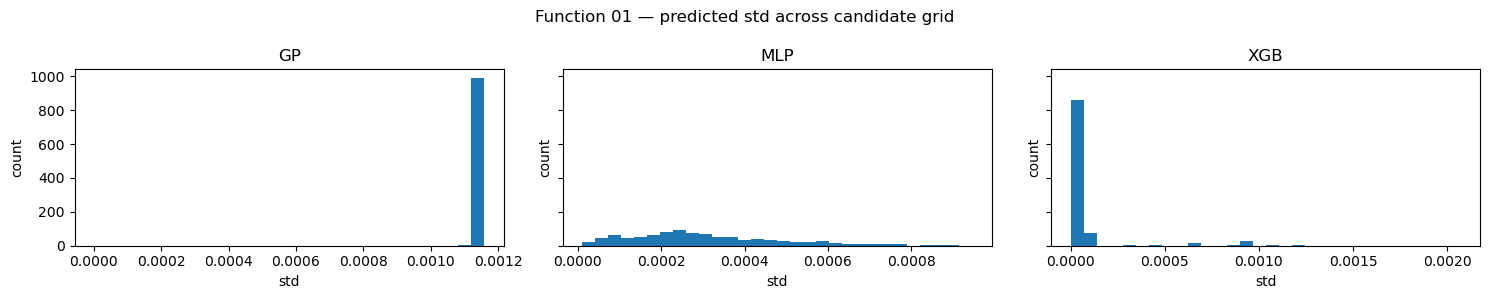

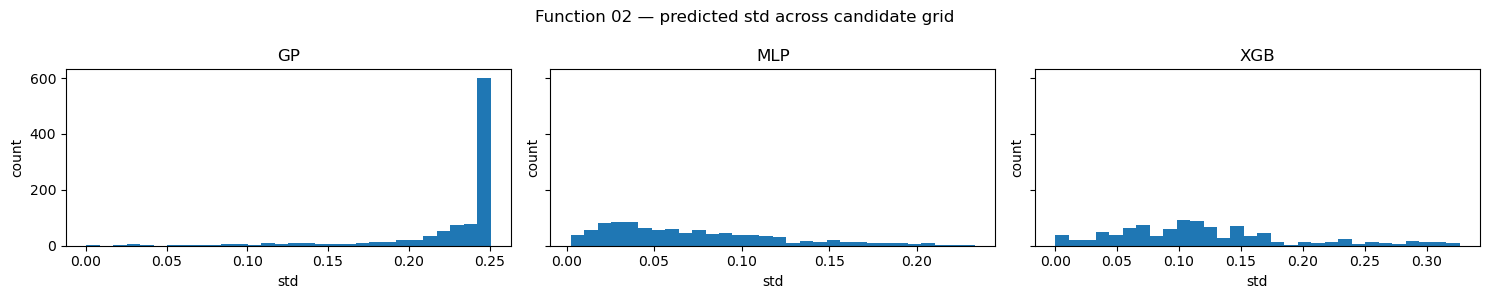

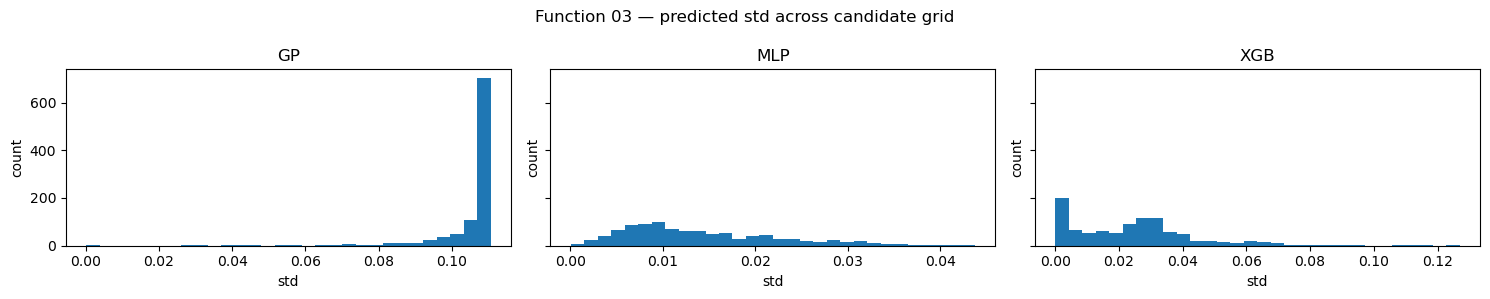

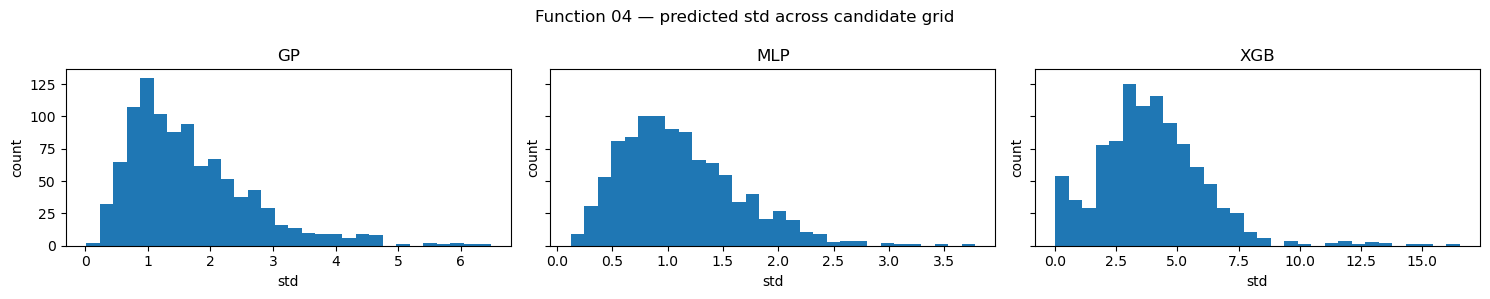

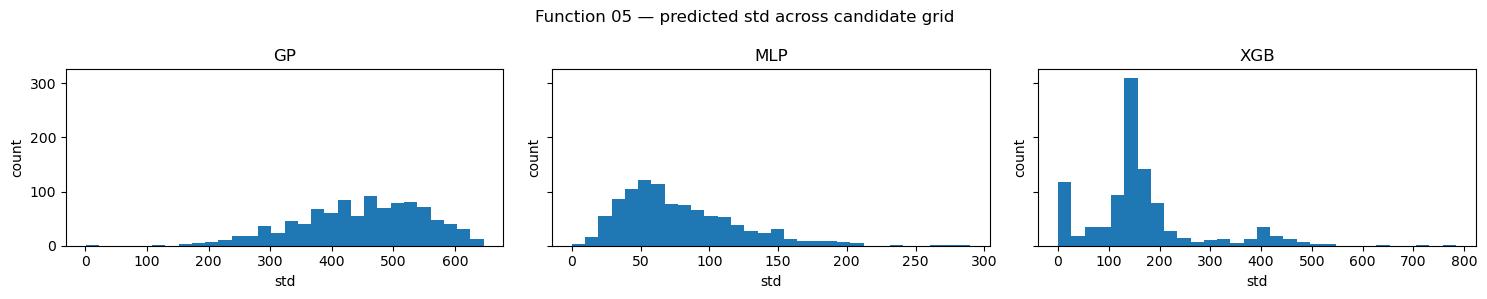

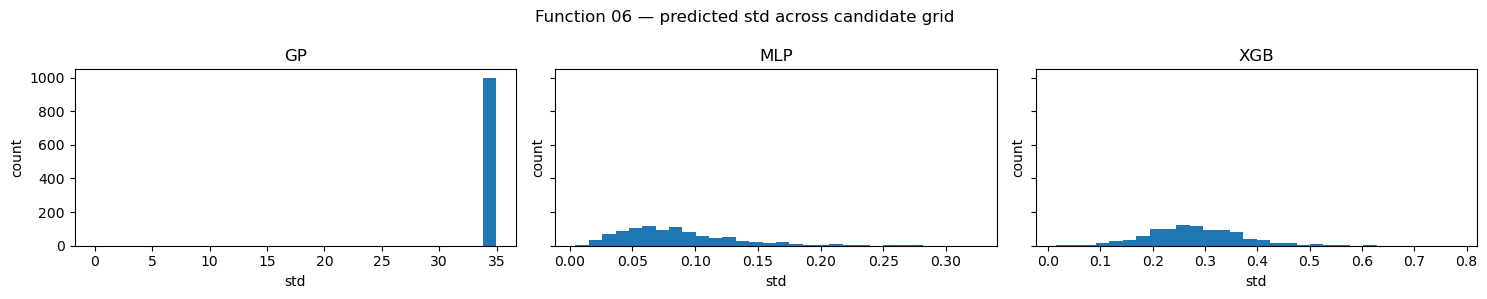

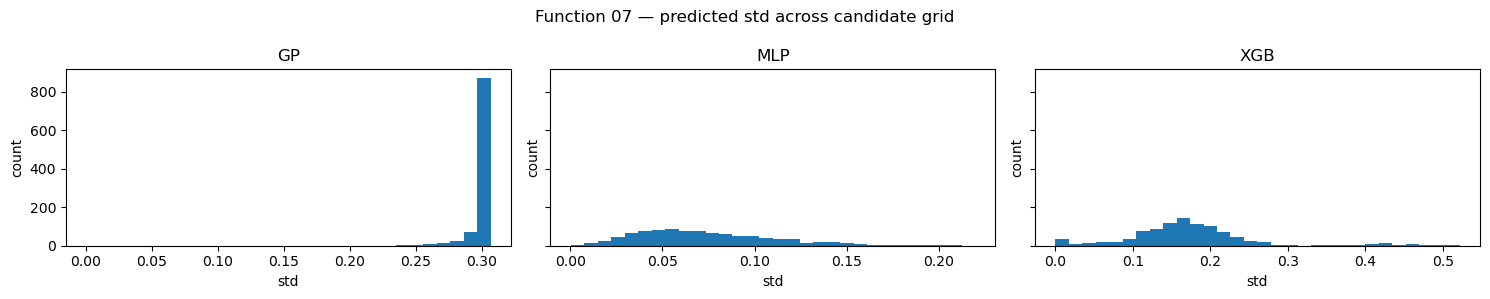

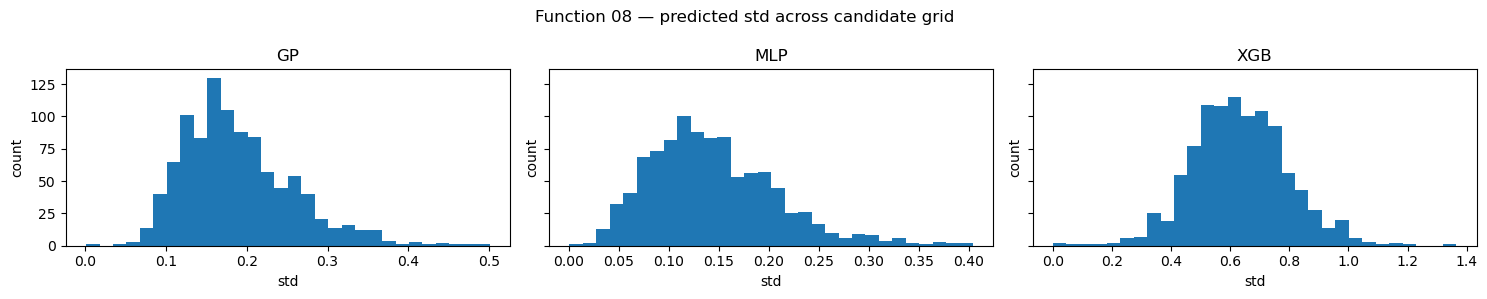

In [7]:
for fn_id, fn_results in results.items():
    methods_ok = [m for m, r in fn_results.items() if not r["error"]]
    if not methods_ok:
        continue

    fig, axes = plt.subplots(1, len(methods_ok), figsize=(5 * len(methods_ok), 3), sharey=True)
    if len(methods_ok) == 1:
        axes = [axes]

    fig.suptitle(f"Function {fn_id:02d} — predicted std across candidate grid", fontsize=12)

    for ax, method in zip(axes, methods_ok):
        std = fn_results[method]["std"]
        ax.hist(std, bins=30, edgecolor="none")
        ax.set_title(method)
        ax.set_xlabel("std")
        ax.set_ylabel("count")

    plt.tight_layout()
    plt.show()

## Summary table

In [8]:
rows = []
for fn_id, fn_results in results.items():
    X, y = get_observations(fn_id)
    for method, res in fn_results.items():
        if res["error"]:
            continue
        rows.append({
            "function":    fn_id,
            "dim":         X.shape[1],
            "n_obs":       len(X),
            "method":      method,
            "y_best":      y.min() if not CONFIG["maximize"] else y.max(),
            "top_score":   res["scores"][0],
            "mean_std":    res["std"].mean().round(4),
        })

df = pd.DataFrame(rows)
df

,function,dim,n_obs,method,y_best,top_score,mean_std
0,1,2,18,GP,2.675288e-09,2.552405e-24,0.0012
1,1,2,18,MLP,2.675288e-09,7.614483e-08,0.0003
2,1,2,18,XGB,2.675288e-09,1.231744e-21,0.0001
3,2,2,17,GP,7.881942e-01,1.855912e-02,0.2282
4,2,2,17,MLP,7.881942e-01,5.122993e-02,0.0715
5,2,2,17,XGB,7.881942e-01,1.023012e-01,0.1207
6,3,3,22,GP,-1.597934e-02,1.561142e-02,0.1053
7,3,3,22,MLP,-1.597934e-02,2.096779e-02,0.0144
8,3,3,22,XGB,-1.597934e-02,1.393597e-02,0.0241
9,4,4,37,GP,2.930421e-02,5.767368e-02,1.6774


---
## Hyperparameter Tuning

Grid search with LOO-CV scoring for each surrogate. Adjust grids and `n_random_trials` below.
Set `n_random_trials=None` to run full grid search, or an integer for random search.

In [ ]:
TUNING_CONFIG = {
    # set to an integer to use random search instead of full grid search
    "n_random_trials": 192,

    "grids": {
        "GP": {
            "kernel":              ["RBF", "Matern"],
            "nu":                  [0.5, 1.5, 2.5],
            "alpha":               [1e-10, 1e-6, 1e-4, 1e-2],
            "length_scale_bounds": [(1e-2, 1e2), (1e-3, 1e3)],
            "n_restarts":          [3, 5, 10],
        },
        "MLP": {
            "hidden":       [4, 8, 16, 32],
            "n_layers":     [1, 2, 3],
            "lr":           [1e-3, 1e-2],
            "weight_decay": [0, 1e-4, 1e-3],
            "epochs":       [50, 100],
            "n_ensemble":   [3, 5, 10],
        },
        "XGB": {
            "n_estimators":    [50, 100, 200, 500],
            "max_depth":       [2, 3, 4],
            "learning_rate":   [0.01, 0.05, 0.1],
            "subsample":       [0.6, 0.8, 1.0],
            "reg_lambda":      [0.1, 1.0, 10.0],
            "quantile_alpha":  [0.1, 0.2],
        },
    },

    "acquisition_grids": {
        "EI":  {"xi":    [0.01, 0.05, 0.1, 0.5]},
        "UCB": {"kappa": [1.0, 2.0, 5.0]},
        "PI":  {"xi":    [0.01, 0.05, 0.1, 0.5]},
    },
}

In [ ]:
from src.tuning import grid_search, tune_acquisition, results_to_table
from src.acquisition import ACQUISITION_REGISTRY

# tuning_results[fn_id][method] = sorted list of {params, loo_rmse, method}
tuning_results = {}

for fn_id in CONFIG["functions"]:
    X, y = get_observations(fn_id)
    if len(X) < 3:
        print(f"function {fn_id:02d}: too few observations for LOO-CV, skipping")
        continue

    tuning_results[fn_id] = {}
    print(f"\nfunction {fn_id:02d} | dim={X.shape[1]} | n_obs={len(X)}")

    for method in CONFIG["methods"]:
        surrogate_cls = SURROGATE_REGISTRY[method]
        param_grid    = TUNING_CONFIG["grids"][method]

        res = grid_search(
            surrogate_cls, param_grid, X, y,
            n_random_trials=TUNING_CONFIG["n_random_trials"],
        )
        tuning_results[fn_id][method] = res
        best = res[0]
        print(f"  {method:4s} | best loo_rmse={best['loo_rmse']:.6g} | {best['method']}")
        print(f"         best params: {best['params']}")


function 01 | dim=2 | n_obs=18


tuning:   0%|          | 0/48 [00:00<?, ?it/s]

  GP   | best loo_rmse=0.000786669 | random_search (n=48/144)
         best params: {'kernel': 'Matern', 'nu': 0.5, 'alpha': 1e-10, 'length_scale_bounds': (0.001, 1000.0), 'n_restarts': 10}


tuning:   0%|          | 0/48 [00:00<?, ?it/s]

  MLP  | best loo_rmse=0.00106274 | random_search (n=48/432)
         best params: {'hidden': 16, 'n_layers': 3, 'lr': 0.01, 'weight_decay': 0, 'epochs': 50, 'n_ensemble': 10}


...

tuning:   0%|          | 0/48 [00:00<?, ?it/s]

  XGB  | best loo_rmse=0.242779 | random_search (n=48/648)
         best params: {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.05, 'subsample': 1.0, 'reg_lambda': 1.0, 'quantile_alpha': 0.1}

function 03 | dim=3 | n_obs=22


tuning:   0%|          | 0/48 [00:00<?, ?it/s]

  GP   | best loo_rmse=0.0501958 | random_search (n=48/144)
         best params: {'kernel': 'RBF', 'nu': 2.5, 'alpha': 0.01, 'length_scale_bounds': (0.001, 1000.0), 'n_restarts': 5}


tuning:   0%|          | 0/48 [00:00<?, ?it/s]

In [12]:
# Acquisition function tuning — run after surrogate tuning
# Uses the best surrogate params found above

acq_tuning_results = {}
acq_name  = CONFIG["acquisition"]
acq_cls   = ACQUISITION_REGISTRY[acq_name]
acq_grid  = TUNING_CONFIG["acquisition_grids"][acq_name]

for fn_id in tuning_results:
    X, y = get_observations(fn_id)
    acq_tuning_results[fn_id] = {}

    for method in CONFIG["methods"]:
        if method not in tuning_results[fn_id]:
            continue
        best_surrogate_params = tuning_results[fn_id][method][0]["params"]
        surrogate_cls = SURROGATE_REGISTRY[method]

        res = tune_acquisition(
            surrogate_cls, best_surrogate_params,
            acq_cls, acq_grid, X, y,
            maximize=CONFIG["maximize"],
        )
        acq_tuning_results[fn_id][method] = res

    best_acq = acq_tuning_results[fn_id]
    print(f"fn {fn_id:02d} acquisition tuning ({acq_name}):")
    for method, res in best_acq.items():
        print(f"  {method:4s} | best acq params={res[0]['params']} | rank_pct={res[0]['rank_percentile']:.3f}")

fn 01 acquisition tuning (EI):
  GP   | best acq params={'xi': 0.01} | rank_pct=1.000
  SVR  | best acq params={'xi': 0.01} | rank_pct=1.000
  MLP  | best acq params={'xi': 0.01} | rank_pct=1.000
fn 02 acquisition tuning (EI):
  GP   | best acq params={'xi': 0.01} | rank_pct=1.000
  SVR  | best acq params={'xi': 0.5} | rank_pct=0.582
  MLP  | best acq params={'xi': 0.5} | rank_pct=0.816
fn 03 acquisition tuning (EI):
  GP   | best acq params={'xi': 0.05} | rank_pct=1.000
  SVR  | best acq params={'xi': 0.5} | rank_pct=0.709
  MLP  | best acq params={'xi': 0.5} | rank_pct=1.000
fn 04 acquisition tuning (EI):
  GP   | best acq params={'xi': 0.5} | rank_pct=0.737
  SVR  | best acq params={'xi': 0.5} | rank_pct=0.587
  MLP  | best acq params={'xi': 0.5} | rank_pct=0.868
fn 05 acquisition tuning (EI):
  GP   | best acq params={'xi': 0.5} | rank_pct=0.993
  SVR  | best acq params={'xi': 0.01} | rank_pct=0.483
  MLP  | best acq params={'xi': 0.01} | rank_pct=0.701
fn 06 acquisition tuning (EI

In [15]:
# Tuning summary table
# model | best_hyperparams | loo_rmse | best_acq_params | rank_percentile | suggested_query

summary_rows = []

for fn_id in tuning_results:
    X, y = get_observations(fn_id)
    y_best = y.max() if CONFIG["maximize"] else y.min()
    rng = np.random.default_rng(42)
    X_candidates = rng.random((CONFIG["n_candidates"], X.shape[1]))

    for method in CONFIG["methods"]:
        if method not in tuning_results[fn_id]:
            continue

        best_params    = tuning_results[fn_id][method][0]["params"]
        best_loo_rmse  = tuning_results[fn_id][method][0]["loo_rmse"]
        best_acq_res   = acq_tuning_results[fn_id][method][0]
        best_acq_params = best_acq_res["params"]
        rank_pct        = best_acq_res["rank_percentile"]

        # generate suggestion with tuned params
        try:
            acq = acq_cls(maximize=CONFIG["maximize"], **best_acq_params)
            model = SURROGATE_REGISTRY[method](**best_params)
            model.fit(X, y)
            mean, std = model.predict(X_candidates)
            X_next, scores = suggest_next(
                X_candidates, mean, std, y_best, acq, n=1, exclude=X
            )
            suggestion = "[" + "-".join(f"{v:.6f}" for v in X_next[0]) + "]"
        except Exception as e:
            suggestion = f"ERROR: {e}"

        summary_rows.append({
            "function":        fn_id,
            "model":           method,
            "loo_rmse":        round(best_loo_rmse, 6),
            "best_hyperparams": str(best_params),
            "best_acq_params": str(best_acq_params),
            "rank_percentile": round(rank_pct, 3),
            "suggested_query": suggestion,
        })

df_tuning = pd.DataFrame(summary_rows)
pd.set_option("display.max_colwidth", 80)
df_tuning

,function,model,loo_rmse,best_hyperparams,best_acq_params,rank_percentile,suggested_query
0,1,GP,0.000959,"{'kernel': 'RBF', 'nu': 1.5, 'alpha': 1e-10, 'length_scale_bounds': (0.001, ...",{'xi': 0.01},1.000,[0.653192-0.672853]
1,1,SVR,0.000931,"{'C': 0.1, 'epsilon': 0.01, 'gamma': 'scale', 'kernel': 'poly'}",{'xi': 0.01},1.000,[0.845699-0.520072]
2,1,MLP,0.000936,"{'hidden': 4, 'n_layers': 1, 'lr': 0.001, 'weight_decay': 0.001, 'epochs': 1...",{'xi': 0.01},1.000,[0.951929-0.012052]
3,2,GP,0.284902,"{'kernel': 'Matern', 'nu': 1.5, 'alpha': 1e-06, 'length_scale_bounds': (0.00...",{'xi': 0.01},1.000,[0.348276-0.865100]
4,2,SVR,0.244779,"{'C': 0.1, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'poly'}",{'xi': 0.5},0.582,[0.004008-0.016580]
5,2,MLP,0.253884,"{'hidden': 32, 'n_layers': 2, 'lr': 0.001, 'weight_decay': 0.001, 'epochs': ...",{'xi': 0.5},0.816,[0.027182-0.958515]
6,3,GP,0.056528,"{'kernel': 'Matern', 'nu': 1.5, 'alpha': 0.0001, 'length_scale_bounds': (0.0...",{'xi': 0.05},1.000,[0.004857-0.729495-0.948874]
7,3,SVR,0.069301,"{'C': 100.0, 'epsilon': 0.01, 'gamma': 'auto', 'kernel': 'rbf'}",{'xi': 0.5},0.709,[0.172944-0.507293-0.991774]
8,3,MLP,0.042534,"{'hidden': 16, 'n_layers': 2, 'lr': 0.01, 'weight_decay': 0.0001, 'epochs': ...",{'xi': 0.5},1.000,[0.053325-0.940351-0.937063]
9,4,GP,1.175587,"{'kernel': 'Matern', 'nu': 2.5, 'alpha': 0.01, 'length_scale_bounds': (0.001...",{'xi': 0.5},0.737,[0.901642-0.984569-0.982367-0.952999]
